In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

print("Uploaded files:")
print(uploaded.keys())

Saving HHS_Unaccompanied_Alien_Children_Program.csv.xlsx to HHS_Unaccompanied_Alien_Children_Program.csv.xlsx
Uploaded files:
dict_keys(['HHS_Unaccompanied_Alien_Children_Program.csv.xlsx'])


In [ ]:
import pandas as pd

# Get the uploaded filename automatically
file_name = list(uploaded.keys())[0]

print("Using file:", file_name)

# Load Excel file
data = pd.read_excel(file_name)

print("\nDataset loaded successfully!")
print("Shape:", data.shape)

display(data.head())

Using file: HHS_Unaccompanied_Alien_Children_Program.csv.xlsx

Dataset loaded successfully!
Shape: (720, 6)


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2025-12-21,6,18,11,2484,14
1,2025-12-18,11,50,6,2472,16
2,2025-12-17,7,31,11,2481,10
3,2025-12-16,8,54,15,2468,9
4,2025-12-15,11,42,9,2470,7


In [ ]:
# Clean column names

data.columns = [
    "date",
    "children_apprehended_cbp",
    "children_in_cbp_custody",
    "children_transferred_out_cbp",
    "children_in_hhs_care",
    "children_discharged_hhs"
]

# Convert date
data["date"] = pd.to_datetime(data["date"], errors="coerce")

# Convert numeric columns
numeric_cols = [
    "children_apprehended_cbp",
    "children_in_cbp_custody",
    "children_transferred_out_cbp",
    "children_in_hhs_care",
    "children_discharged_hhs"
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Sort chronologically
data = data.sort_values("date").reset_index(drop=True)

print("Data preparation complete!")
print("\nColumns:")
print(data.columns.tolist())

print("\nDate range:")
print(data["date"].min(), "to", data["date"].max())

print("\nShape:")
print(data.shape)

Data preparation complete!

Columns:
['date', 'children_apprehended_cbp', 'children_in_cbp_custody', 'children_transferred_out_cbp', 'children_in_hhs_care', 'children_discharged_hhs']

Date range:
2023-01-12 00:00:00 to 2025-12-21 00:00:00

Shape:
(720, 6)


In [ ]:
# ============================================================
# STEP 2: DERIVED HEALTHCARE CAPACITY METRICS
# ============================================================

# ------------------------------------------------------------
# 1. TOTAL SYSTEM LOAD
# ------------------------------------------------------------
# Total children currently under CBP + HHS care

data["total_system_load"] = (
    data["children_in_cbp_custody"]
    + data["children_in_hhs_care"]
)

# ------------------------------------------------------------
# 2. NET INTAKE PRESSURE
# ------------------------------------------------------------
# Positive = more children entering HHS than leaving
# Negative = more children discharged than transferred in

data["net_intake_pressure"] = (
    data["children_transferred_out_cbp"]
    - data["children_discharged_hhs"]
)

# ------------------------------------------------------------
# 3. CARE LOAD GROWTH RATE
# ------------------------------------------------------------
# Day-to-day percentage change in total system load

data["care_load_growth_rate"] = (
    data["total_system_load"]
    .pct_change()
    * 100
)

# Replace infinite values if any occur
data["care_load_growth_rate"] = (
    data["care_load_growth_rate"]
    .replace([np.inf, -np.inf], np.nan)
)

# ------------------------------------------------------------
# 4. 7-DAY ROLLING NET INTAKE
# ------------------------------------------------------------

data["net_intake_7day_avg"] = (
    data["net_intake_pressure"]
    .rolling(window=7, min_periods=1)
    .mean()
)

# ------------------------------------------------------------
# 5. 14-DAY ROLLING NET INTAKE
# ------------------------------------------------------------

data["net_intake_14day_avg"] = (
    data["net_intake_pressure"]
    .rolling(window=14, min_periods=1)
    .mean()
)

# ------------------------------------------------------------
# 6. 7-DAY ROLLING SYSTEM LOAD
# ------------------------------------------------------------

data["system_load_7day_avg"] = (
    data["total_system_load"]
    .rolling(window=7, min_periods=1)
    .mean()
)

# ------------------------------------------------------------
# 7. 14-DAY ROLLING SYSTEM LOAD
# ------------------------------------------------------------

data["system_load_14day_avg"] = (
    data["total_system_load"]
    .rolling(window=14, min_periods=1)
    .mean()
)

# ------------------------------------------------------------
# 8. BACKLOG INDICATOR
# ------------------------------------------------------------
# Sustained positive intake pressure indicates increasing
# care-system pressure.

data["backlog_indicator"] = (
    data["net_intake_7day_avg"] > 0
)

# ------------------------------------------------------------
# 9. CAPACITY PRESSURE CLASSIFICATION
# ------------------------------------------------------------

data["capacity_pressure"] = np.select(
    [
        data["net_intake_7day_avg"] > 50,
        data["net_intake_7day_avg"] > 0,
        data["net_intake_7day_avg"] < 0
    ],
    [
        "High Pressure",
        "Moderate Pressure",
        "Relief"
    ],
    default="Balanced"
)

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("=" * 70)
print("STEP 2: CAPACITY METRICS COMPLETED")
print("=" * 70)

print("\nDerived columns:")
print([
    "total_system_load",
    "net_intake_pressure",
    "care_load_growth_rate",
    "net_intake_7day_avg",
    "net_intake_14day_avg",
    "system_load_7day_avg",
    "system_load_14day_avg",
    "backlog_indicator",
    "capacity_pressure"
])

print("\nSample of derived metrics:")
display(
    data[
        [
            "date",
            "total_system_load",
            "net_intake_pressure",
            "care_load_growth_rate",
            "net_intake_7day_avg",
            "capacity_pressure"
        ]
    ].head(15)
)

print("\nCapacity pressure counts:")
print(data["capacity_pressure"].value_counts())

print("\nSTEP 2 COMPLETE!")

STEP 2: CAPACITY METRICS COMPLETED

Derived columns:
['total_system_load', 'net_intake_pressure', 'care_load_growth_rate', 'net_intake_7day_avg', 'net_intake_14day_avg', 'system_load_7day_avg', 'system_load_14day_avg', 'backlog_indicator', 'capacity_pressure']

Sample of derived metrics:


,date,total_system_load,net_intake_pressure,care_load_growth_rate,net_intake_7day_avg,capacity_pressure
0,2023-01-12,6619,-402,NaN,-402.000000,Relief
1,2023-01-22,7171,-188,8.339628,-295.000000,Relief
2,2023-01-23,7330,-142,2.217264,-244.000000,Relief
3,2023-01-24,7475,-128,1.978172,-215.000000,Relief
4,2023-01-25,7560,-139,1.137124,-199.800000,Relief
5,2023-01-29,7517,-292,-0.568783,-215.166667,Relief
6,2023-01-30,7797,-167,3.724890,-208.285714,Relief
7,2023-01-31,7839,-122,0.538669,-168.285714,Relief
8,2023-02-01,7935,-204,1.224646,-170.571429,Relief
9,2023-02-02,7892,-275,-0.541903,-189.571429,Relief



Capacity pressure counts:
capacity_pressure
Relief               468
Moderate Pressure    205
High Pressure         45
Balanced               2
Name: count, dtype: int64

STEP 2 COMPLETE!


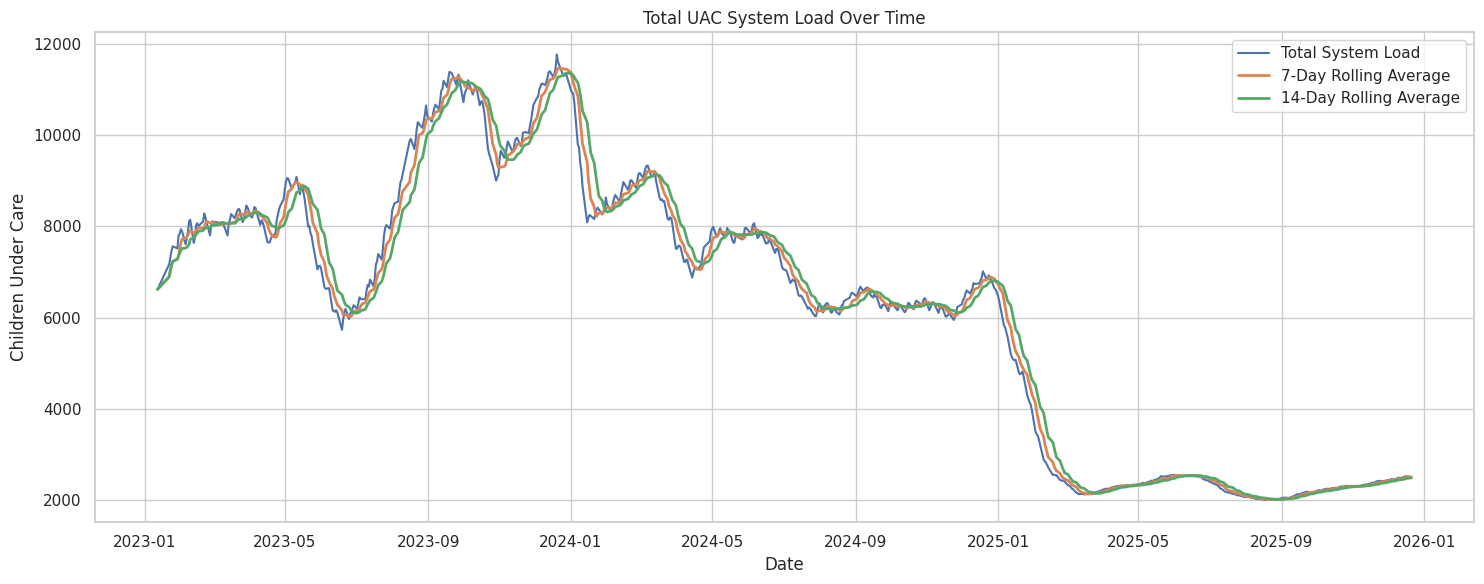

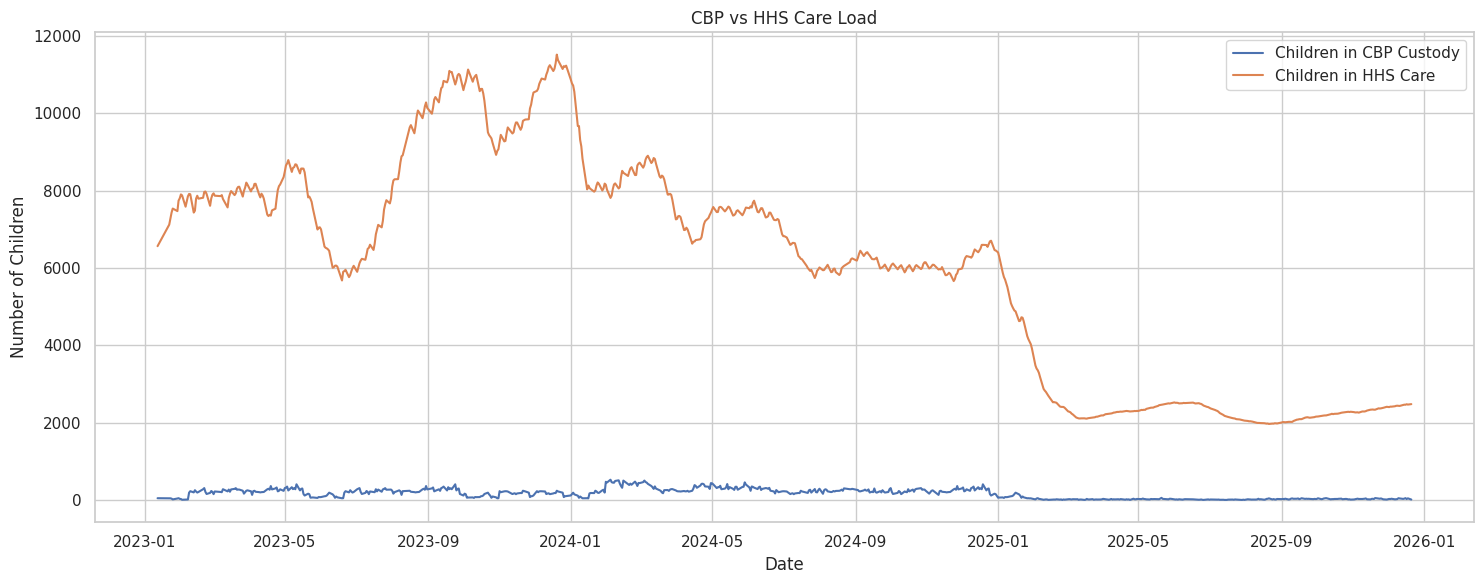

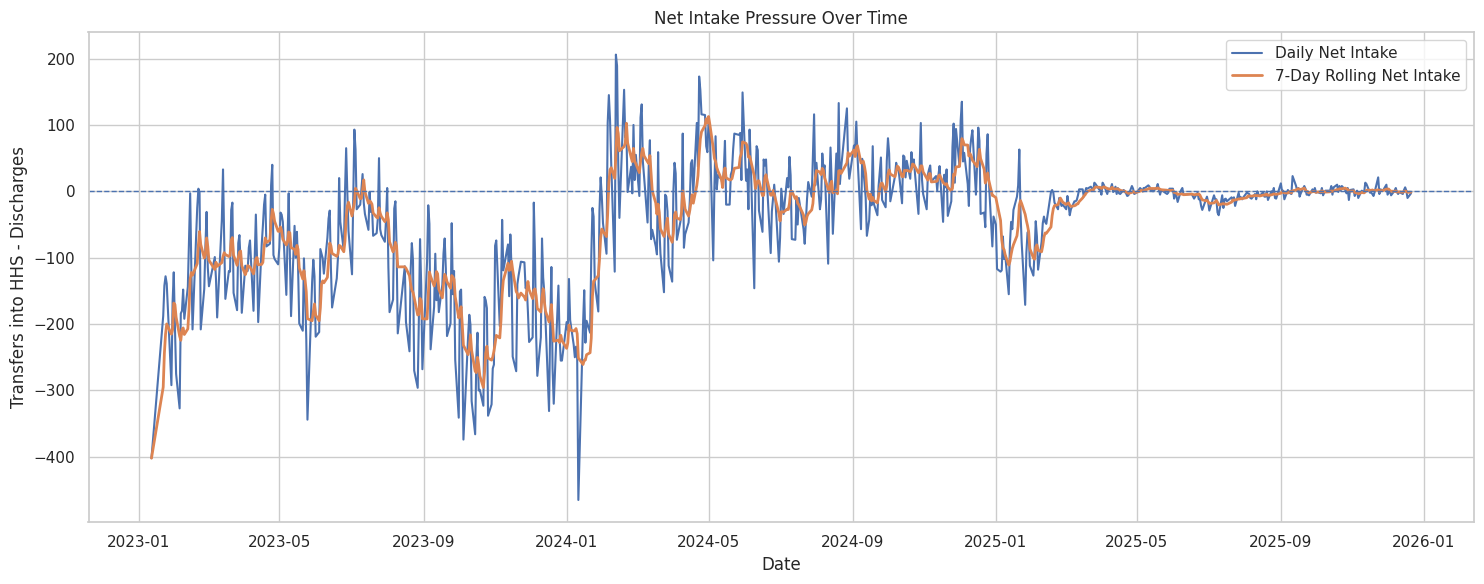

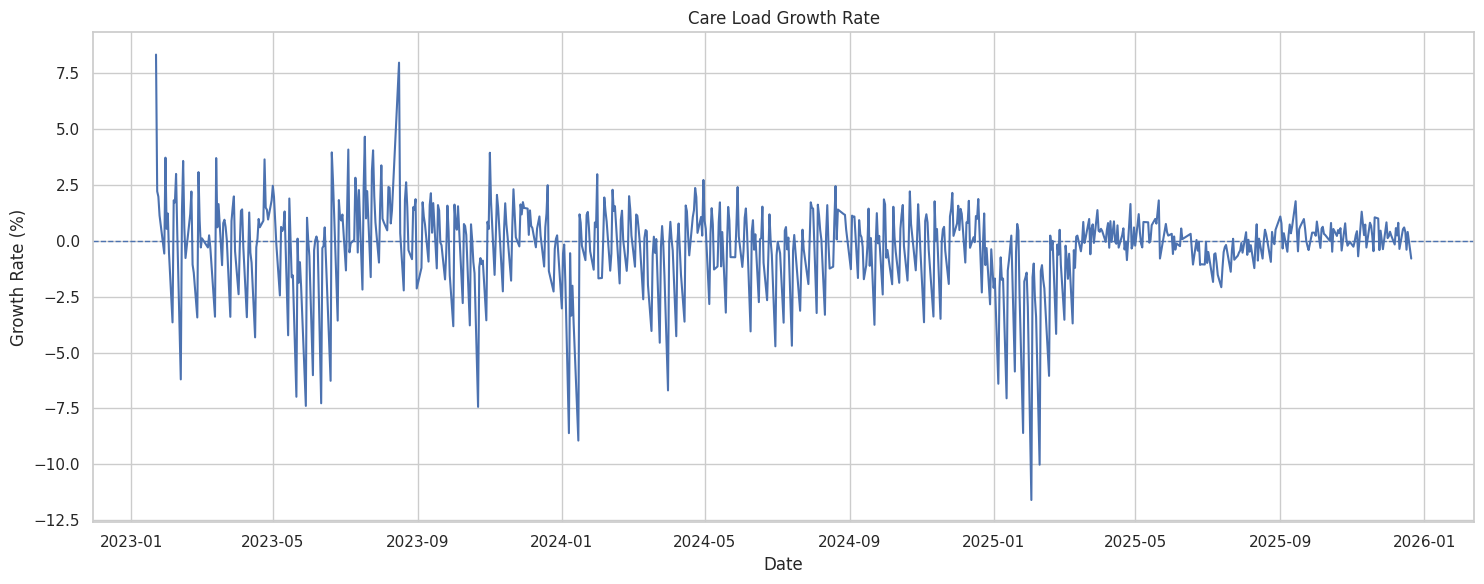

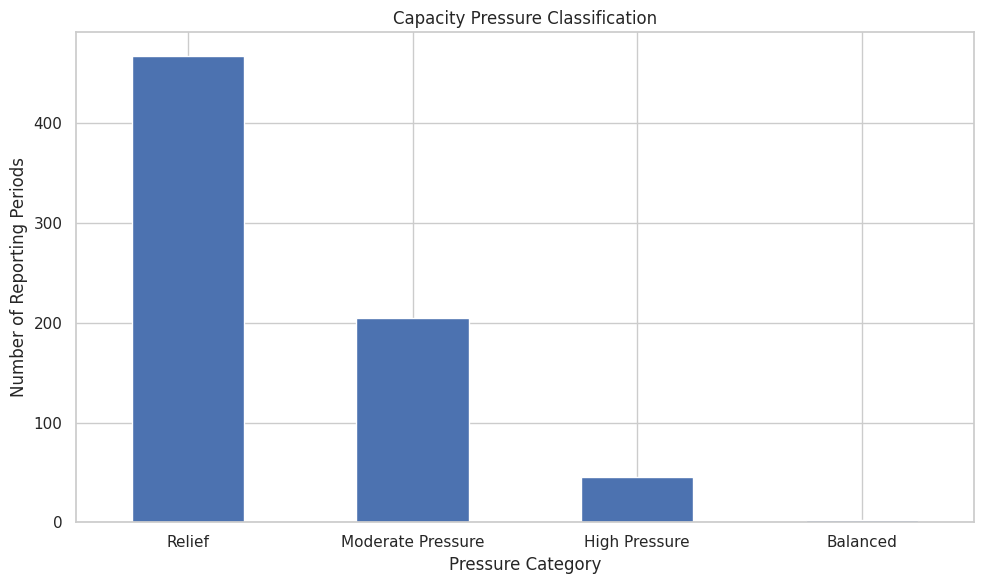

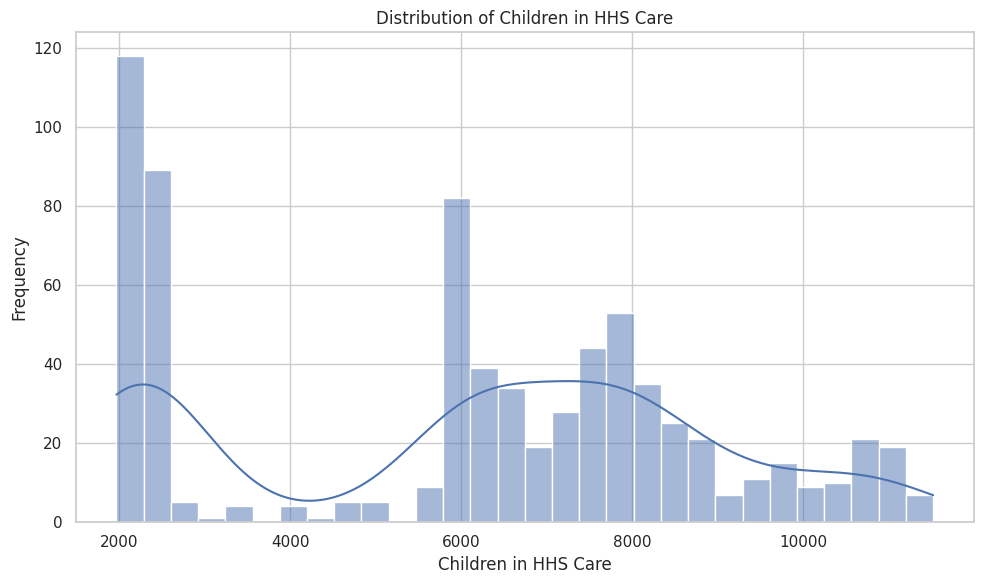

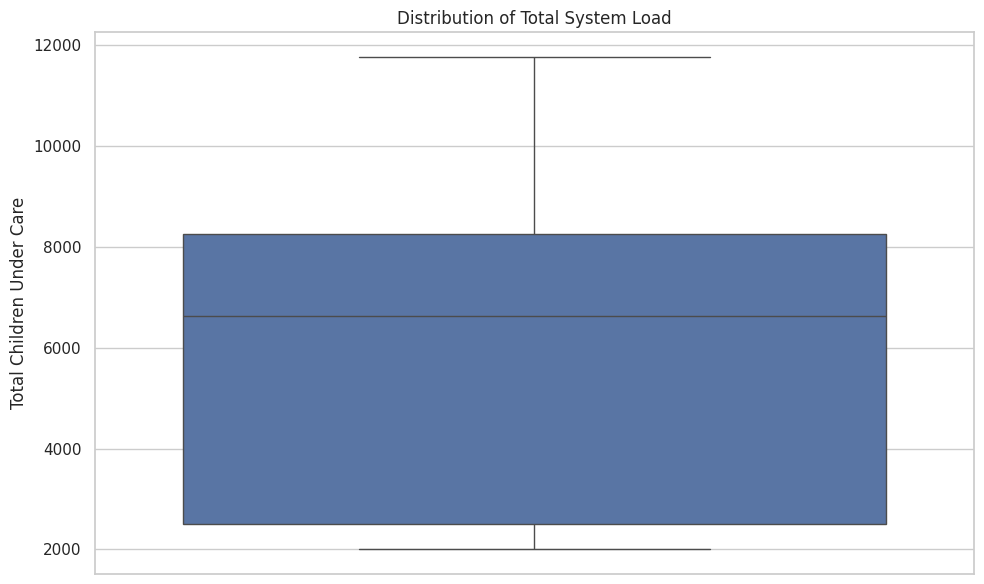

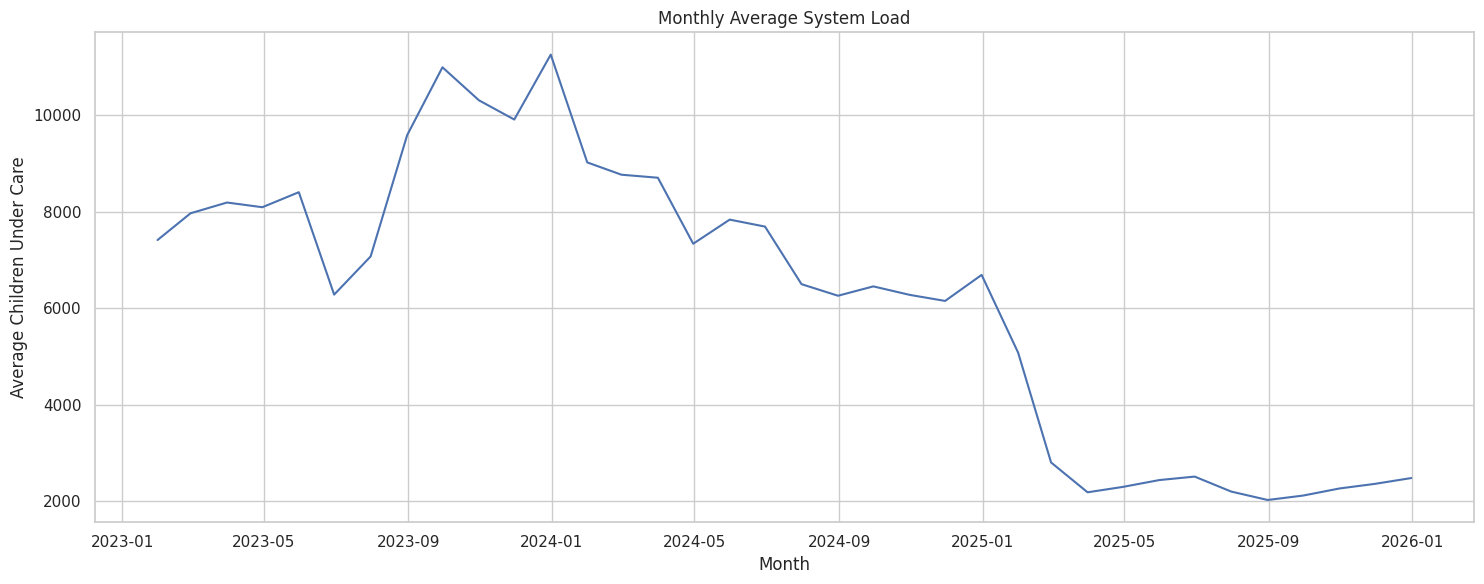

STEP 3 COMPLETE


In [ ]:
# ============================================================
# STEP 3: EDA + CAPACITY STRESS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# 1. SYSTEM LOAD OVER TIME
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    data["date"],
    data["total_system_load"],
    label="Total System Load"
)

plt.plot(
    data["date"],
    data["system_load_7day_avg"],
    label="7-Day Rolling Average",
    linewidth=2
)

plt.plot(
    data["date"],
    data["system_load_14day_avg"],
    label="14-Day Rolling Average",
    linewidth=2
)

plt.title("Total UAC System Load Over Time")
plt.xlabel("Date")
plt.ylabel("Children Under Care")
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. CBP LOAD VS HHS LOAD
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    data["date"],
    data["children_in_cbp_custody"],
    label="Children in CBP Custody"
)

plt.plot(
    data["date"],
    data["children_in_hhs_care"],
    label="Children in HHS Care"
)

plt.title("CBP vs HHS Care Load")
plt.xlabel("Date")
plt.ylabel("Number of Children")
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. NET INTAKE PRESSURE
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    data["date"],
    data["net_intake_pressure"],
    label="Daily Net Intake"
)

plt.plot(
    data["date"],
    data["net_intake_7day_avg"],
    label="7-Day Rolling Net Intake",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Net Intake Pressure Over Time")
plt.xlabel("Date")
plt.ylabel("Transfers into HHS - Discharges")
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. CARE LOAD GROWTH RATE
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    data["date"],
    data["care_load_growth_rate"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Care Load Growth Rate")
plt.xlabel("Date")
plt.ylabel("Growth Rate (%)")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. CAPACITY PRESSURE DISTRIBUTION
# ------------------------------------------------------------

pressure_counts = data["capacity_pressure"].value_counts()

plt.figure(figsize=(10, 6))

pressure_counts.plot(
    kind="bar"
)

plt.title("Capacity Pressure Classification")
plt.xlabel("Pressure Category")
plt.ylabel("Number of Reporting Periods")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. HHS CARE LOAD DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    data["children_in_hhs_care"],
    bins=30,
    kde=True
)

plt.title("Distribution of Children in HHS Care")
plt.xlabel("Children in HHS Care")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. SYSTEM LOAD BOXPLOT
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    y=data["total_system_load"]
)

plt.title("Distribution of Total System Load")
plt.ylabel("Total Children Under Care")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. MONTHLY SYSTEM LOAD
# ------------------------------------------------------------

monthly_load = (
    data
    .set_index("date")["total_system_load"]
    .resample("ME")
    .mean()
)

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_load.index,
    monthly_load.values
)

plt.title("Monthly Average System Load")
plt.xlabel("Month")
plt.ylabel("Average Children Under Care")

plt.tight_layout()
plt.show()


print("=" * 70)
print("STEP 3 COMPLETE")
print("=" * 70)

In [ ]:
# ============================================================
# STEP 4: CAPACITY KPIs + STRESS PERIOD DETECTION
# ============================================================

# ------------------------------------------------------------
# KPI 1: TOTAL CHILDREN UNDER CARE
# ------------------------------------------------------------
# System-wide responsibility:
# CBP custody + HHS care

data["total_children_under_care"] = (
    data["children_in_cbp_custody"]
    + data["children_in_hhs_care"]
)


# ------------------------------------------------------------
# KPI 2: NET INTAKE PRESSURE
# ------------------------------------------------------------
# Positive = transfers into HHS exceed discharges
# Negative = discharges exceed transfers

data["net_intake_kpi"] = (
    data["children_transferred_out_cbp"]
    - data["children_discharged_hhs"]
)


# ------------------------------------------------------------
# KPI 3: CARE LOAD VOLATILITY INDEX
# ------------------------------------------------------------
# Measures how much the system load changes from one
# reporting period to the next.
#
# Higher value = more unstable / variable care load.

data["care_load_volatility_index"] = (
    data["total_children_under_care"]
    .pct_change()
    .abs()
    * 100
)

data["care_load_volatility_index"] = (
    data["care_load_volatility_index"]
    .replace([np.inf, -np.inf], np.nan)
)


# ------------------------------------------------------------
# KPI 4: BACKLOG ACCUMULATION RATE
# ------------------------------------------------------------
# Positive rolling net intake indicates sustained pressure.
#
# We use a 7-period rolling average to reduce the effect
# of individual reporting-day fluctuations.

data["backlog_accumulation_rate"] = (
    data["net_intake_kpi"]
    .rolling(
        window=7,
        min_periods=1
    )
    .mean()
)


# ------------------------------------------------------------
# KPI 5: DISCHARGE OFFSET RATIO
# ------------------------------------------------------------
# Measures how much of the incoming HHS flow is offset
# by HHS discharges.
#
# Ratio near 1 = discharges approximately match transfers.
# Below 1 = transfers exceed discharges.
# Above 1 = discharges exceed transfers.

data["discharge_offset_ratio"] = np.where(
    data["children_transferred_out_cbp"] > 0,
    data["children_discharged_hhs"]
    / data["children_transferred_out_cbp"],
    np.nan
)

# Convert to percentage
data["discharge_offset_percent"] = (
    data["discharge_offset_ratio"] * 100
)


# ============================================================
# CAPACITY STRESS SCORE
# ============================================================

# Create percentile-based thresholds from the actual dataset.

load_threshold = data["total_children_under_care"].quantile(0.90)

pressure_threshold = data["backlog_accumulation_rate"].quantile(0.75)

volatility_threshold = (
    data["care_load_volatility_index"]
    .quantile(0.75)
)


# ------------------------------------------------------------
# CAPACITY STRESS FLAG
# ------------------------------------------------------------

data["capacity_stress_flag"] = (
    (data["total_children_under_care"] >= load_threshold)
    &
    (data["backlog_accumulation_rate"] >= pressure_threshold)
)


# ------------------------------------------------------------
# RELIEF FLAG
# ------------------------------------------------------------

relief_threshold = (
    data["backlog_accumulation_rate"].quantile(0.25)
)

data["capacity_relief_flag"] = (
    (data["total_children_under_care"] <=
     data["total_children_under_care"].quantile(0.25))
    &
    (data["backlog_accumulation_rate"] <= relief_threshold)
)


# ============================================================
# KPI SUMMARY
# ============================================================

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Children Under Care",
        "Net Intake Pressure",
        "Care Load Volatility Index",
        "Backlog Accumulation Rate",
        "Discharge Offset Ratio (%)"
    ],

    "Mean": [
        data["total_children_under_care"].mean(),
        data["net_intake_kpi"].mean(),
        data["care_load_volatility_index"].mean(),
        data["backlog_accumulation_rate"].mean(),
        data["discharge_offset_percent"].mean()
    ],

    "Median": [
        data["total_children_under_care"].median(),
        data["net_intake_kpi"].median(),
        data["care_load_volatility_index"].median(),
        data["backlog_accumulation_rate"].median(),
        data["discharge_offset_percent"].median()
    ],

    "Minimum": [
        data["total_children_under_care"].min(),
        data["net_intake_kpi"].min(),
        data["care_load_volatility_index"].min(),
        data["backlog_accumulation_rate"].min(),
        data["discharge_offset_percent"].min()
    ],

    "Maximum": [
        data["total_children_under_care"].max(),
        data["net_intake_kpi"].max(),
        data["care_load_volatility_index"].max(),
        data["backlog_accumulation_rate"].max(),
        data["discharge_offset_percent"].max()
    ]
})


# ============================================================
# TOP CAPACITY STRESS PERIODS
# ============================================================

stress_periods = (
    data[
        data["capacity_stress_flag"]
    ]
    [
        [
            "date",
            "total_children_under_care",
            "net_intake_kpi",
            "backlog_accumulation_rate",
            "care_load_volatility_index",
            "children_in_cbp_custody",
            "children_in_hhs_care"
        ]
    ]
    .sort_values(
        "total_children_under_care",
        ascending=False
    )
    .head(15)
)


# ============================================================
# TOP RELIEF PERIODS
# ============================================================

relief_periods = (
    data[
        data["capacity_relief_flag"]
    ]
    [
        [
            "date",
            "total_children_under_care",
            "net_intake_kpi",
            "backlog_accumulation_rate",
            "children_in_cbp_custody",
            "children_in_hhs_care"
        ]
    ]
    .sort_values(
        "total_children_under_care"
    )
    .head(10)
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 70)
print("STEP 4: CAPACITY KPI ANALYSIS")
print("=" * 70)

print("\nKPI SUMMARY:")
display(kpi_summary.round(2))


print("\nCapacity thresholds:")
print(
    "90th percentile system load:",
    round(load_threshold, 2)
)

print(
    "75th percentile backlog pressure:",
    round(pressure_threshold, 2)
)

print(
    "75th percentile volatility:",
    round(volatility_threshold, 2)
)


print("\nNumber of capacity stress periods:")
print(data["capacity_stress_flag"].sum())


print("\nNumber of capacity relief periods:")
print(data["capacity_relief_flag"].sum())


print("\nTOP CAPACITY STRESS PERIODS:")
display(stress_periods.round(2))


print("\nTOP RELIEF PERIODS:")
display(relief_periods.round(2))


print("\nSTEP 4 COMPLETE!")
print("=" * 70)

STEP 4: CAPACITY KPI ANALYSIS

KPI SUMMARY:


,KPI,Mean,Median,Minimum,Maximum
0,Total Children Under Care,6232.77,6633.50,2002.0,11762.00
1,Net Intake Pressure,-44.74,-11.50,-465.0,206.00
2,Care Load Volatility Index,1.25,0.82,0.0,11.60
3,Backlog Accumulation Rate,-45.94,-11.50,-402.0,112.71
4,Discharge Offset Ratio (%),201.35,127.80,0.0,4327.27



Capacity thresholds:
90th percentile system load: 9920.9
75th percentile backlog pressure: 3.71
75th percentile volatility: 1.59

Number of capacity stress periods:
0

Number of capacity relief periods:
0

TOP CAPACITY STRESS PERIODS:


,date,total_children_under_care,net_intake_kpi,backlog_accumulation_rate,care_load_volatility_index,children_in_cbp_custody,children_in_hhs_care



TOP RELIEF PERIODS:


,date,total_children_under_care,net_intake_kpi,backlog_accumulation_rate,children_in_cbp_custody,children_in_hhs_care



STEP 4 COMPLETE!


In [ ]:
# ============================================================
# STEP 4B: REFINED CAPACITY STRESS & RELIEF DETECTION
# ============================================================

# ------------------------------------------------------------
# REFINE DISCHARGE OFFSET RATIO
# ------------------------------------------------------------
# Ignore extremely small transfer volumes because they can
# create artificially huge ratios.

data["discharge_offset_ratio_clean"] = np.where(
    data["children_transferred_out_cbp"] >= 20,
    (
        data["children_discharged_hhs"]
        / data["children_transferred_out_cbp"]
    ) * 100,
    np.nan
)

# ------------------------------------------------------------
# SYSTEM LOAD THRESHOLDS
# ------------------------------------------------------------

high_load_threshold = (
    data["total_children_under_care"].quantile(0.90)
)

low_load_threshold = (
    data["total_children_under_care"].quantile(0.25)
)

# ------------------------------------------------------------
# BACKLOG PRESSURE THRESHOLDS
# ------------------------------------------------------------

high_pressure_threshold = (
    data["net_intake_7day_avg"].quantile(0.75)
)

low_pressure_threshold = (
    data["net_intake_7day_avg"].quantile(0.25)
)

# ------------------------------------------------------------
# HIGH CAPACITY STRESS
# ------------------------------------------------------------
# High system load AND positive sustained pressure

data["high_capacity_stress"] = (
    (data["total_children_under_care"] >= high_load_threshold)
    &
    (data["net_intake_7day_avg"] > 0)
)

# ------------------------------------------------------------
# CAPACITY RELIEF
# ------------------------------------------------------------
# Lower system load AND negative sustained pressure

data["capacity_relief"] = (
    (data["total_children_under_care"] <= low_load_threshold)
    &
    (data["net_intake_7day_avg"] < 0)
)

# ------------------------------------------------------------
# TOP STRESS PERIODS
# ------------------------------------------------------------

top_stress = (
    data[data["high_capacity_stress"]]
    [
        [
            "date",
            "total_children_under_care",
            "net_intake_7day_avg",
            "children_in_cbp_custody",
            "children_in_hhs_care"
        ]
    ]
    .sort_values(
        "total_children_under_care",
        ascending=False
    )
    .head(15)
)

# ------------------------------------------------------------
# TOP RELIEF PERIODS
# ------------------------------------------------------------

top_relief = (
    data[data["capacity_relief"]]
    [
        [
            "date",
            "total_children_under_care",
            "net_intake_7day_avg",
            "children_in_cbp_custody",
            "children_in_hhs_care"
        ]
    ]
    .sort_values(
        "total_children_under_care"
    )
    .head(15)
)

# ------------------------------------------------------------
# FINAL KPI SUMMARY
# ------------------------------------------------------------

final_kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Children Under Care",
        "Net Intake Pressure",
        "Care Load Volatility Index",
        "Backlog Accumulation Rate",
        "Discharge Offset Ratio (%)"
    ],

    "Mean": [
        data["total_children_under_care"].mean(),
        data["net_intake_kpi"].mean(),
        data["care_load_volatility_index"].mean(),
        data["backlog_accumulation_rate"].mean(),
        data["discharge_offset_ratio_clean"].mean()
    ],

    "Median": [
        data["total_children_under_care"].median(),
        data["net_intake_kpi"].median(),
        data["care_load_volatility_index"].median(),
        data["backlog_accumulation_rate"].median(),
        data["discharge_offset_ratio_clean"].median()
    ],

    "Minimum": [
        data["total_children_under_care"].min(),
        data["net_intake_kpi"].min(),
        data["care_load_volatility_index"].min(),
        data["backlog_accumulation_rate"].min(),
        data["discharge_offset_ratio_clean"].min()
    ],

    "Maximum": [
        data["total_children_under_care"].max(),
        data["net_intake_kpi"].max(),
        data["care_load_volatility_index"].max(),
        data["backlog_accumulation_rate"].max(),
        data["discharge_offset_ratio_clean"].max()
    ]
})

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 70)
print("REFINED CAPACITY ANALYSIS")
print("=" * 70)

print("\nFINAL KPI SUMMARY:")
display(final_kpi_summary.round(2))

print(
    "\nHigh capacity stress periods:",
    data["high_capacity_stress"].sum()
)

print(
    "Capacity relief periods:",
    data["capacity_relief"].sum()
)

print("\nTOP CAPACITY STRESS PERIODS:")
display(top_stress.round(2))

print("\nTOP CAPACITY RELIEF PERIODS:")
display(top_relief.round(2))

print("\nDischarge offset ratio handling:")
print(
    "Ratios were calculated only when daily transfers were >= 20 children."
)

print("\nSTEP 4B COMPLETE!")

REFINED CAPACITY ANALYSIS

FINAL KPI SUMMARY:


,KPI,Mean,Median,Minimum,Maximum
0,Total Children Under Care,6232.77,6633.50,2002.00,11762.00
1,Net Intake Pressure,-44.74,-11.50,-465.00,206.00
2,Care Load Volatility Index,1.25,0.82,0.00,11.60
3,Backlog Accumulation Rate,-45.94,-11.50,-402.00,112.71
4,Discharge Offset Ratio (%),167.76,124.79,4.55,1295.65



High capacity stress periods: 0
Capacity relief periods: 104

TOP CAPACITY STRESS PERIODS:


,date,total_children_under_care,net_intake_7day_avg,children_in_cbp_custody,children_in_hhs_care



TOP CAPACITY RELIEF PERIODS:


,date,total_children_under_care,net_intake_7day_avg,children_in_cbp_custody,children_in_hhs_care
638,2025-08-24,2002,-5.29,21,1981
633,2025-08-17,2005,-5.71,14,1991
634,2025-08-18,2005,-5.29,20,1985
641,2025-08-27,2007,-4.14,19,1988
639,2025-08-25,2010,-4.71,30,1980
640,2025-08-26,2010,-3.86,21,1989
635,2025-08-19,2015,-5.86,35,1980
642,2025-08-28,2017,-4.57,33,1984
631,2025-08-13,2019,-6.57,22,1997
637,2025-08-21,2021,-6.00,49,1972



Discharge offset ratio handling:
Ratios were calculated only when daily transfers were >= 20 children.

STEP 4B COMPLETE!


In [ ]:
# ============================================================
# STEP 5: HIGH-LOAD PERIODS & PROLONGED CAPACITY STRESS
# ============================================================

print("=" * 70)
print("STEP 5: HIGH-LOAD & PROLONGED STRESS ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. HIGH SYSTEM LOAD THRESHOLDS
# ------------------------------------------------------------

p75_load = data["total_children_under_care"].quantile(0.75)
p90_load = data["total_children_under_care"].quantile(0.90)
p95_load = data["total_children_under_care"].quantile(0.95)

print("\nSystem Load Thresholds:")
print(f"75th percentile: {p75_load:.2f}")
print(f"90th percentile: {p90_load:.2f}")
print(f"95th percentile: {p95_load:.2f}")


# ------------------------------------------------------------
# 2. CLASSIFY SYSTEM LOAD
# ------------------------------------------------------------

data["load_level"] = "Normal"

data.loc[
    data["total_children_under_care"] >= p75_load,
    "load_level"
] = "Elevated"

data.loc[
    data["total_children_under_care"] >= p90_load,
    "load_level"
] = "High"

data.loc[
    data["total_children_under_care"] >= p95_load,
    "load_level"
] = "Very High"


# ------------------------------------------------------------
# 3. LOAD LEVEL COUNTS
# ------------------------------------------------------------

load_counts = data["load_level"].value_counts()

print("\nSystem Load Classification:")
display(load_counts.to_frame("Number of Periods"))


# ------------------------------------------------------------
# 4. TOP 20 HIGHEST SYSTEM LOAD PERIODS
# ------------------------------------------------------------

top_high_load = (
    data[
        [
            "date",
            "total_children_under_care",
            "children_in_cbp_custody",
            "children_in_hhs_care",
            "net_intake_kpi",
            "net_intake_7day_avg",
            "load_level"
        ]
    ]
    .sort_values(
        "total_children_under_care",
        ascending=False
    )
    .head(20)
)

print("\nTOP 20 HIGHEST SYSTEM LOAD PERIODS:")
display(top_high_load.round(2))


# ------------------------------------------------------------
# 5. PROLONGED HIGH-LOAD WINDOWS
# ------------------------------------------------------------
# A prolonged stress window is defined as at least
# 3 consecutive reporting periods at or above the 90th
# percentile of system load.

data["high_load_flag"] = (
    data["total_children_under_care"] >= p90_load
)


# Identify consecutive groups
data["high_load_group"] = (
    data["high_load_flag"]
    .ne(data["high_load_flag"].shift())
    .cumsum()
)


stress_windows = (
    data[data["high_load_flag"]]
    .groupby("high_load_group")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        periods=("date", "count"),
        peak_load=("total_children_under_care", "max"),
        average_load=("total_children_under_care", "mean")
    )
    .reset_index(drop=True)
)

# Keep windows lasting at least 3 reporting periods
stress_windows = stress_windows[
    stress_windows["periods"] >= 3
].sort_values(
    "peak_load",
    ascending=False
)


print("\nPROLONGED HIGH-LOAD WINDOWS:")
display(stress_windows.round(2))


# ------------------------------------------------------------
# 6. PEAK SYSTEM LOAD
# ------------------------------------------------------------

peak_row = data.loc[
    data["total_children_under_care"].idxmax()
]

print("\nPEAK SYSTEM LOAD:")
print(
    f"Date: {peak_row['date'].date()}"
)

print(
    f"Total children under care: "
    f"{peak_row['total_children_under_care']:.0f}"
)

print(
    f"CBP custody: "
    f"{peak_row['children_in_cbp_custody']:.0f}"
)

print(
    f"HHS care: "
    f"{peak_row['children_in_hhs_care']:.0f}"
)


# ------------------------------------------------------------
# 7. LOWEST SYSTEM LOAD
# ------------------------------------------------------------

low_row = data.loc[
    data["total_children_under_care"].idxmin()
]

print("\nLOWEST SYSTEM LOAD:")
print(
    f"Date: {low_row['date'].date()}"
)

print(
    f"Total children under care: "
    f"{low_row['total_children_under_care']:.0f}"
)

print(
    f"CBP custody: "
    f"{low_row['children_in_cbp_custody']:.0f}"
)

print(
    f"HHS care: "
    f"{low_row['children_in_hhs_care']:.0f}"
)


# ------------------------------------------------------------
# 8. YEARLY CAPACITY SUMMARY
# ------------------------------------------------------------

data["year"] = data["date"].dt.year

yearly_capacity = (
    data
    .groupby("year")
    .agg(
        average_system_load=(
            "total_children_under_care",
            "mean"
        ),
        peak_system_load=(
            "total_children_under_care",
            "max"
        ),
        average_net_intake=(
            "net_intake_kpi",
            "mean"
        ),
        average_hhs_care=(
            "children_in_hhs_care",
            "mean"
        ),
        average_cbp_care=(
            "children_in_cbp_custody",
            "mean"
        )
    )
    .reset_index()
)

print("\nYEARLY CAPACITY SUMMARY:")
display(yearly_capacity.round(2))


print("\nSTEP 5 COMPLETE!")
print("=" * 70)

STEP 5: HIGH-LOAD & PROLONGED STRESS ANALYSIS

System Load Thresholds:
75th percentile: 8249.50
90th percentile: 9920.90
95th percentile: 10964.30

System Load Classification:


,Number of Periods
load_level,
Normal,540
Elevated,108
High,36
Very High,36



TOP 20 HIGHEST SYSTEM LOAD PERIODS:


,date,total_children_under_care,children_in_cbp_custody,children_in_hhs_care,net_intake_kpi,net_intake_7day_avg,load_level
224,2023-12-20,11762,246,11516,-267,-198.57,Very High
225,2023-12-21,11603,228,11375,-320,-225.71,Very High
223,2023-12-19,11476,185,11291,-114,-170.57,Very High
220,2023-12-14,11399,157,11242,-195,-180.57,Very High
161,2023-09-19,11382,287,11095,-71,-125.14,Very High
162,2023-09-20,11374,310,11064,-117,-128.43,Very High
219,2023-12-13,11373,181,11192,-153,-166.14,Very High
163,2023-09-21,11352,285,11067,-218,-136.14,Very High
226,2023-12-25,11340,196,11144,-142,-224.14,Very High
222,2023-12-18,11337,188,11149,-200,-185.71,Very High



PROLONGED HIGH-LOAD WINDOWS:


,start_date,end_date,periods,peak_load,average_load
2,2023-11-21,2024-01-04,30,11762,10975.10
0,2023-08-22,2023-10-19,41,11382,10817.56



PEAK SYSTEM LOAD:
Date: 2023-12-20
Total children under care: 11762
CBP custody: 246
HHS care: 11516

LOWEST SYSTEM LOAD:
Date: 2025-08-24
Total children under care: 2002
CBP custody: 21
HHS care: 1981

YEARLY CAPACITY SUMMARY:


,year,average_system_load,peak_system_load,average_net_intake,average_hhs_care,average_cbp_care
0,2023,8846.54,11762,-130.96,8646.07,200.47
1,2024,7319.86,10994,3.44,7042.96,276.90
2,2025,2575.74,6471,-12.36,2542.84,32.91



STEP 5 COMPLETE!


STEP 6: SYSTEM LOAD FORECASTING

Forecast model:
Linear Regression

Mean Absolute Error (MAE): 1346.06
Root Mean Squared Error (RMSE): 1584.95

Model trend slope: -11.78 children per reporting period

FORECAST SUMMARY:
Last observed system load: 2502
Forecast load after 30 reporting periods: 1644.95
Maximum forecast load: 1986.53
Minimum forecast load: 1644.95

NEXT 30-PERIOD FORECAST:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,date,forecast_system_load
0,2025-12-22,1986.53
1,2025-12-23,1974.76
2,2025-12-24,1962.98
3,2025-12-25,1951.20
4,2025-12-26,1939.42
5,2025-12-27,1927.64
6,2025-12-28,1915.86
7,2025-12-29,1904.08
8,2025-12-30,1892.31
9,2025-12-31,1880.53


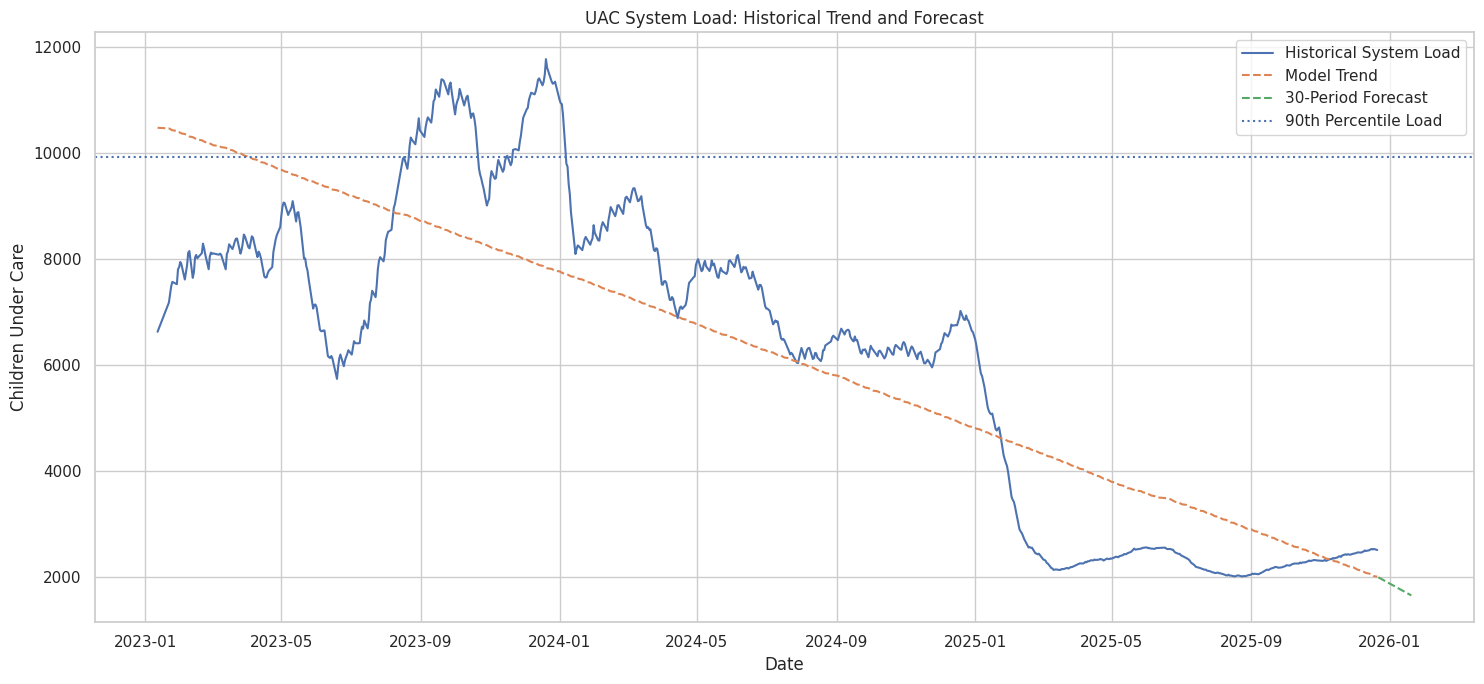


STEP 6 COMPLETE!


In [ ]:
# ============================================================
# STEP 6: SYSTEM LOAD FORECASTING
# ============================================================

from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("STEP 6: SYSTEM LOAD FORECASTING")
print("=" * 70)

# ------------------------------------------------------------
# PREPARE FORECAST DATA
# ------------------------------------------------------------

forecast_data = data[
    [
        "date",
        "total_children_under_care"
    ]
].dropna().copy()

forecast_data = forecast_data.sort_values("date")

# Sequential reporting-period index
forecast_data["period_index"] = np.arange(
    len(forecast_data)
)

# ------------------------------------------------------------
# TRAINING DATA
# ------------------------------------------------------------

X = forecast_data[["period_index"]]

y = forecast_data["total_children_under_care"]

# ------------------------------------------------------------
# LINEAR REGRESSION MODEL
# ------------------------------------------------------------

model = LinearRegression()

model.fit(X, y)

# Historical fitted values
forecast_data["fitted_load"] = model.predict(X)

# ------------------------------------------------------------
# FORECAST NEXT 30 REPORTING PERIODS
# ------------------------------------------------------------

forecast_periods = 30

future_index = np.arange(
    len(forecast_data),
    len(forecast_data) + forecast_periods
)

future_load = model.predict(
    future_index.reshape(-1, 1)
)

# ------------------------------------------------------------
# CREATE FORECAST TABLE
# ------------------------------------------------------------

last_date = forecast_data["date"].max()

# Approximate future reporting dates using 1-day increments
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_periods,
    freq="D"
)

forecast = pd.DataFrame({
    "date": future_dates,
    "forecast_system_load": future_load
})

# Prevent negative forecast values
forecast["forecast_system_load"] = (
    forecast["forecast_system_load"]
    .clip(lower=0)
)

# ------------------------------------------------------------
# MODEL PERFORMANCE
# ------------------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(
    y,
    forecast_data["fitted_load"]
)

rmse = np.sqrt(
    mean_squared_error(
        y,
        forecast_data["fitted_load"]
    )
)

print("\nForecast model:")
print("Linear Regression")

print(
    f"\nMean Absolute Error (MAE): {mae:.2f}"
)

print(
    f"Root Mean Squared Error (RMSE): {rmse:.2f}"
)

print(
    f"\nModel trend slope: "
    f"{model.coef_[0]:.2f} children per reporting period"
)

# ------------------------------------------------------------
# FORECAST SUMMARY
# ------------------------------------------------------------

print("\nFORECAST SUMMARY:")

print(
    "Last observed system load:",
    round(
        forecast_data["total_children_under_care"].iloc[-1],
        2
    )
)

print(
    "Forecast load after 30 reporting periods:",
    round(
        forecast["forecast_system_load"].iloc[-1],
        2
    )
)

print(
    "Maximum forecast load:",
    round(
        forecast["forecast_system_load"].max(),
        2
    )
)

print(
    "Minimum forecast load:",
    round(
        forecast["forecast_system_load"].min(),
        2
    )
)


# ------------------------------------------------------------
# DISPLAY FORECAST
# ------------------------------------------------------------

print("\nNEXT 30-PERIOD FORECAST:")
display(
    forecast.round(2)
)


# ============================================================
# FORECAST VISUALIZATION
# ============================================================

plt.figure(figsize=(15, 7))

plt.plot(
    forecast_data["date"],
    forecast_data["total_children_under_care"],
    label="Historical System Load"
)

plt.plot(
    forecast_data["date"],
    forecast_data["fitted_load"],
    linestyle="--",
    label="Model Trend"
)

plt.plot(
    forecast["date"],
    forecast["forecast_system_load"],
    linestyle="--",
    label="30-Period Forecast"
)

plt.axhline(
    p90_load,
    linestyle=":",
    label="90th Percentile Load"
)

plt.title(
    "UAC System Load: Historical Trend and Forecast"
)

plt.xlabel("Date")

plt.ylabel("Children Under Care")

plt.legend()

plt.tight_layout()

plt.show()


print("\nSTEP 6 COMPLETE!")
print("=" * 70)

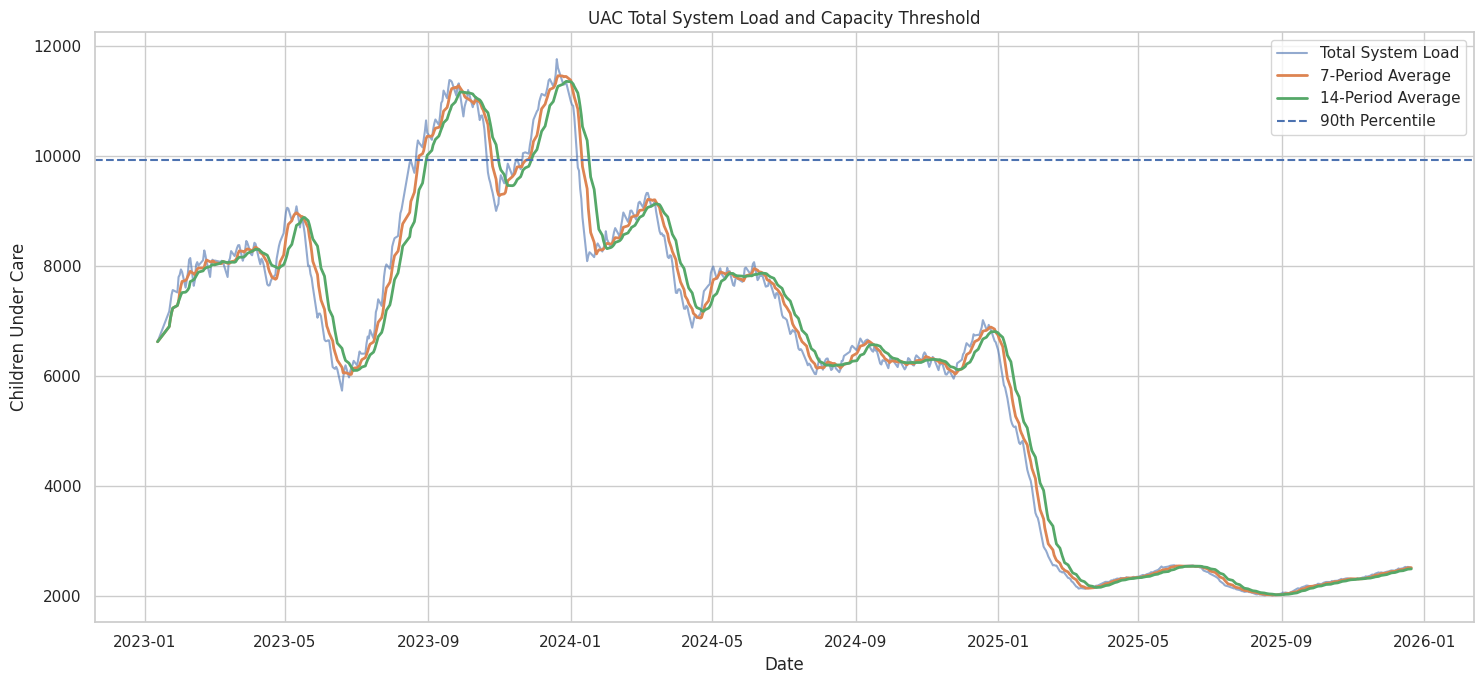

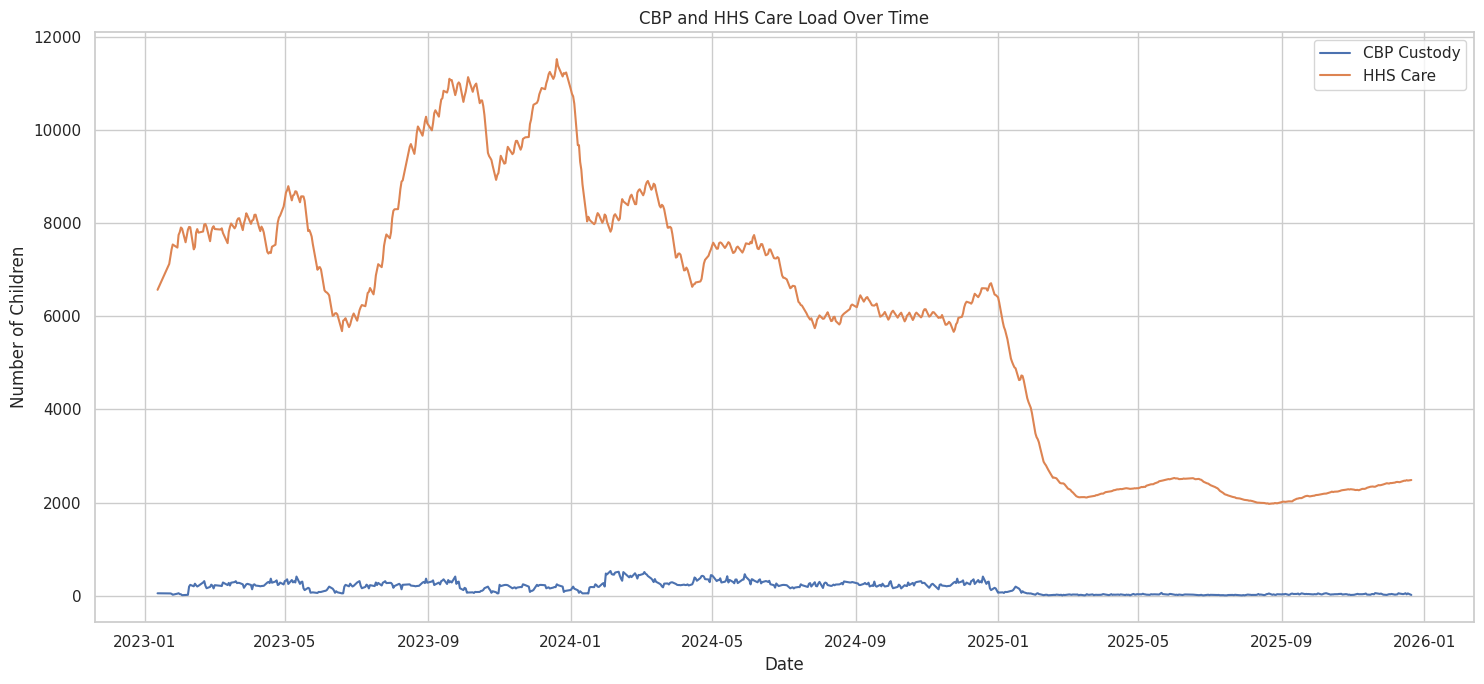

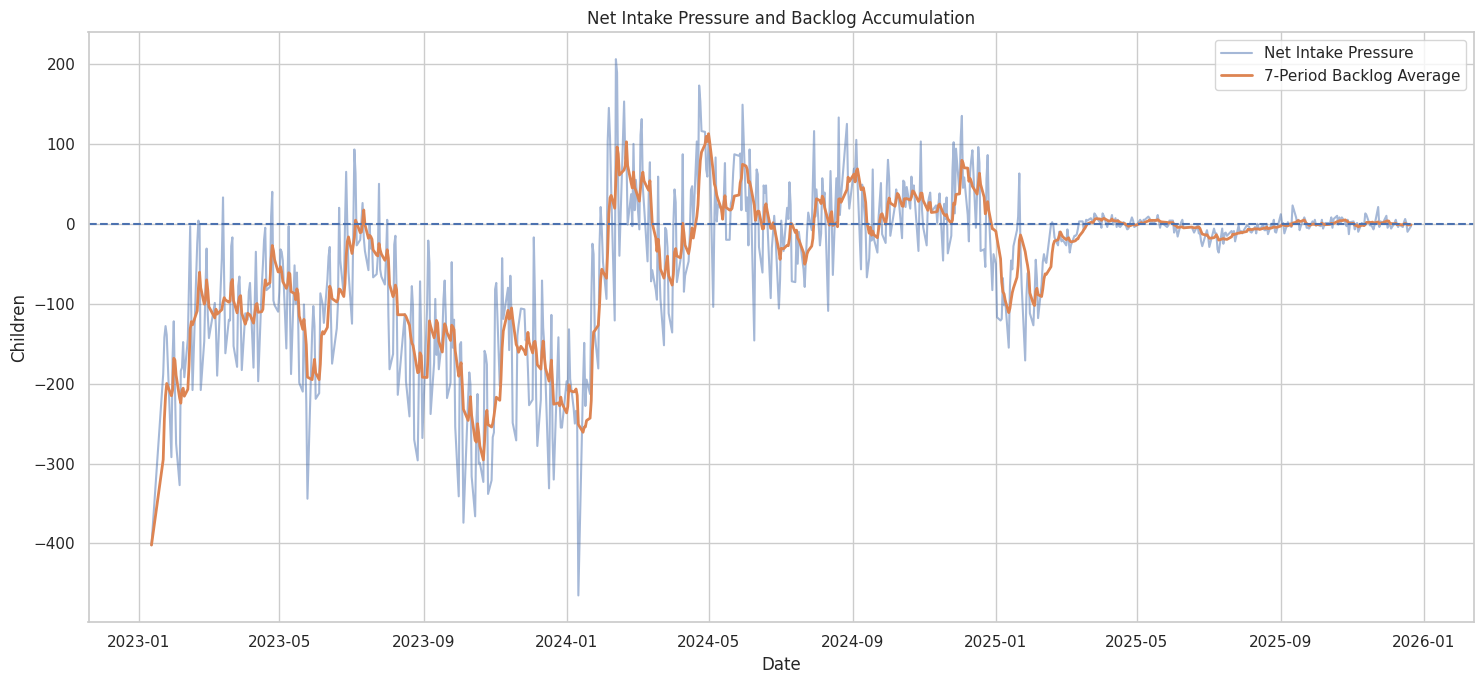

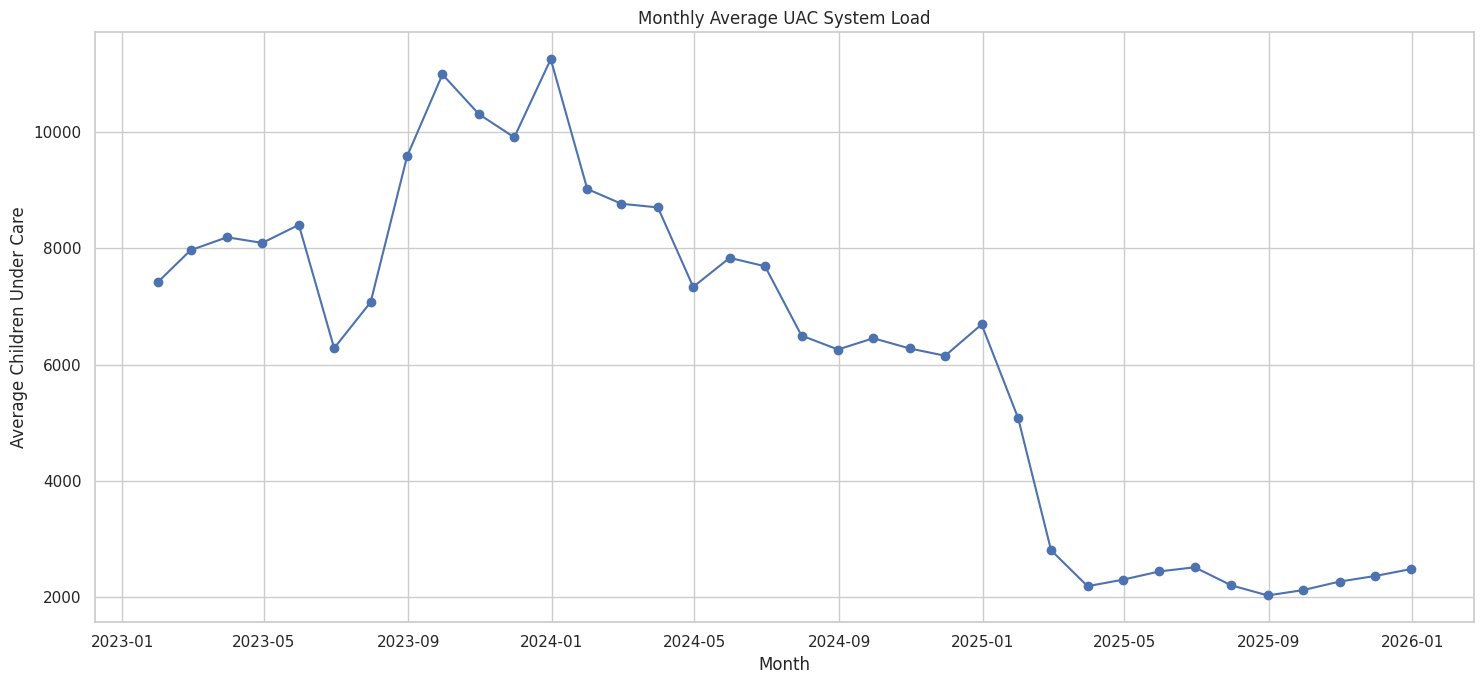

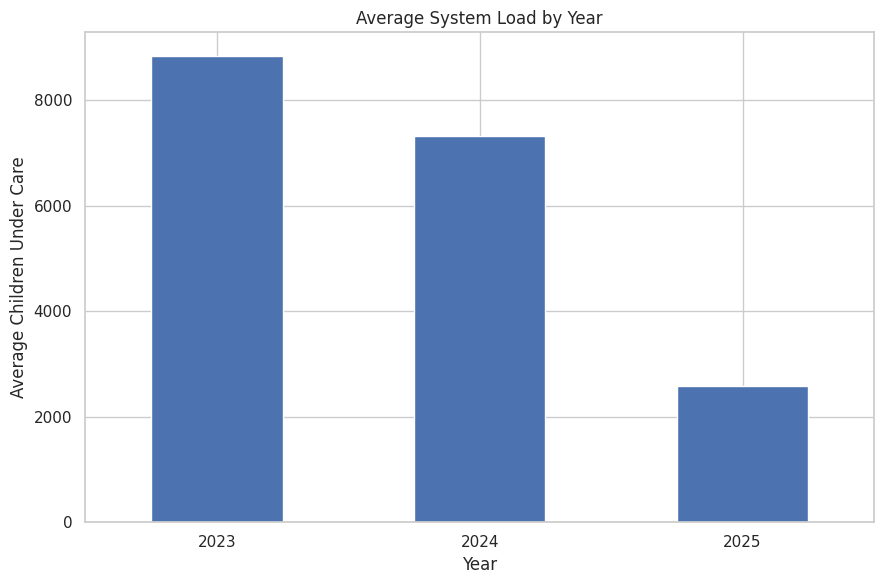

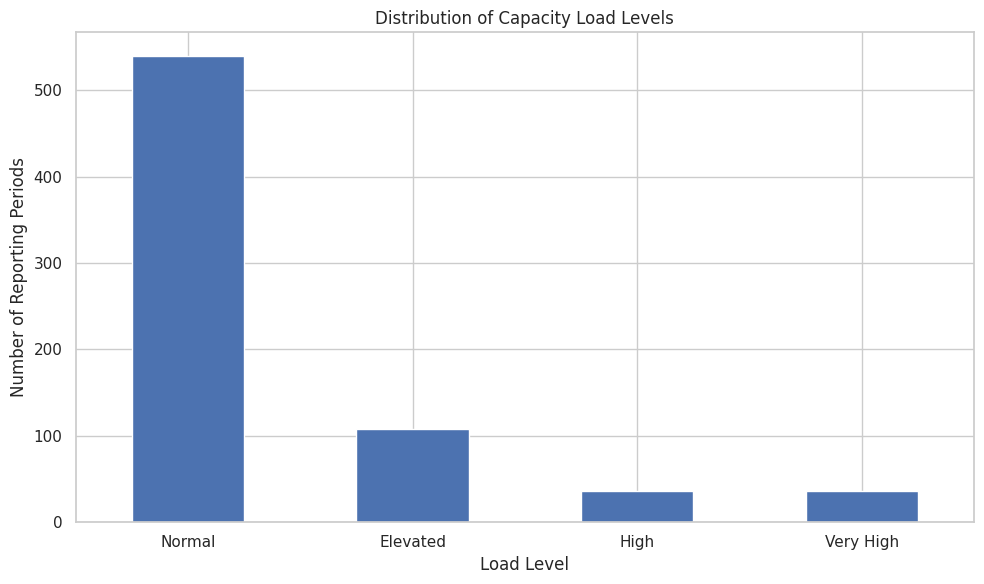

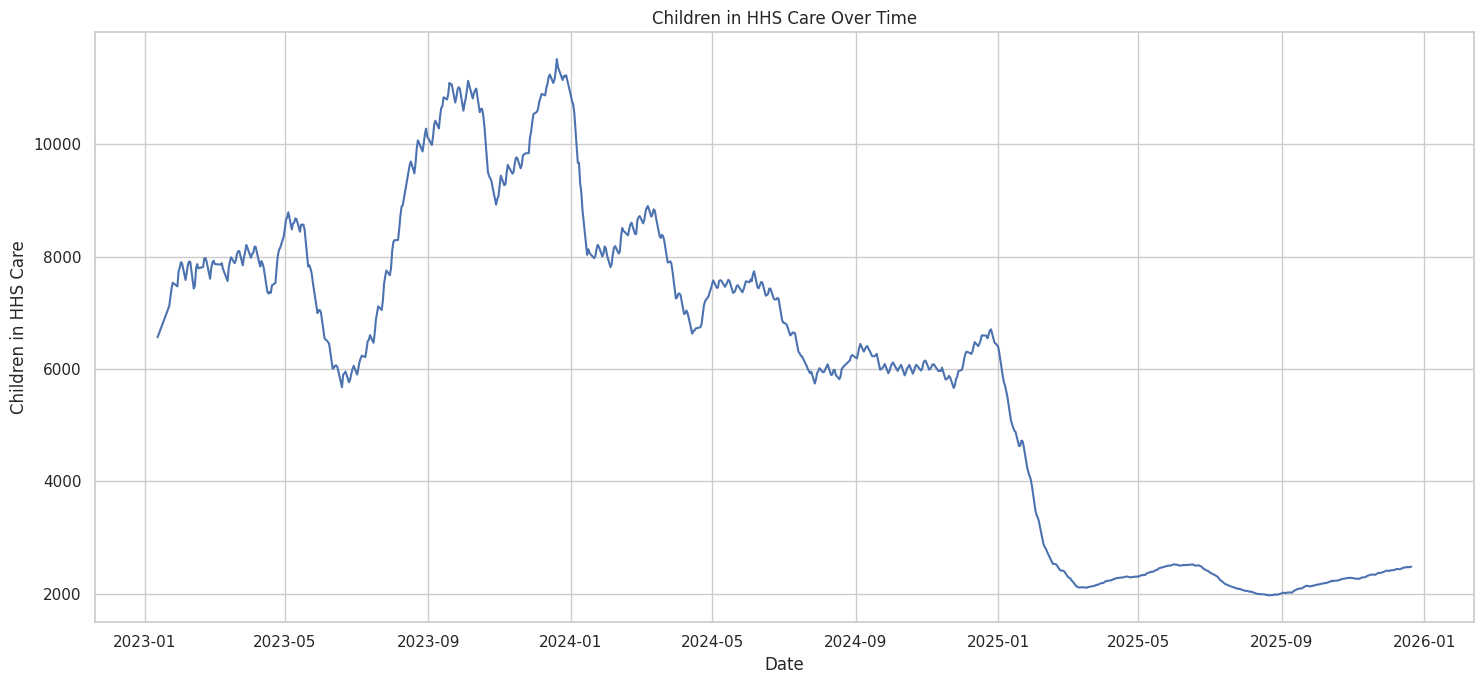

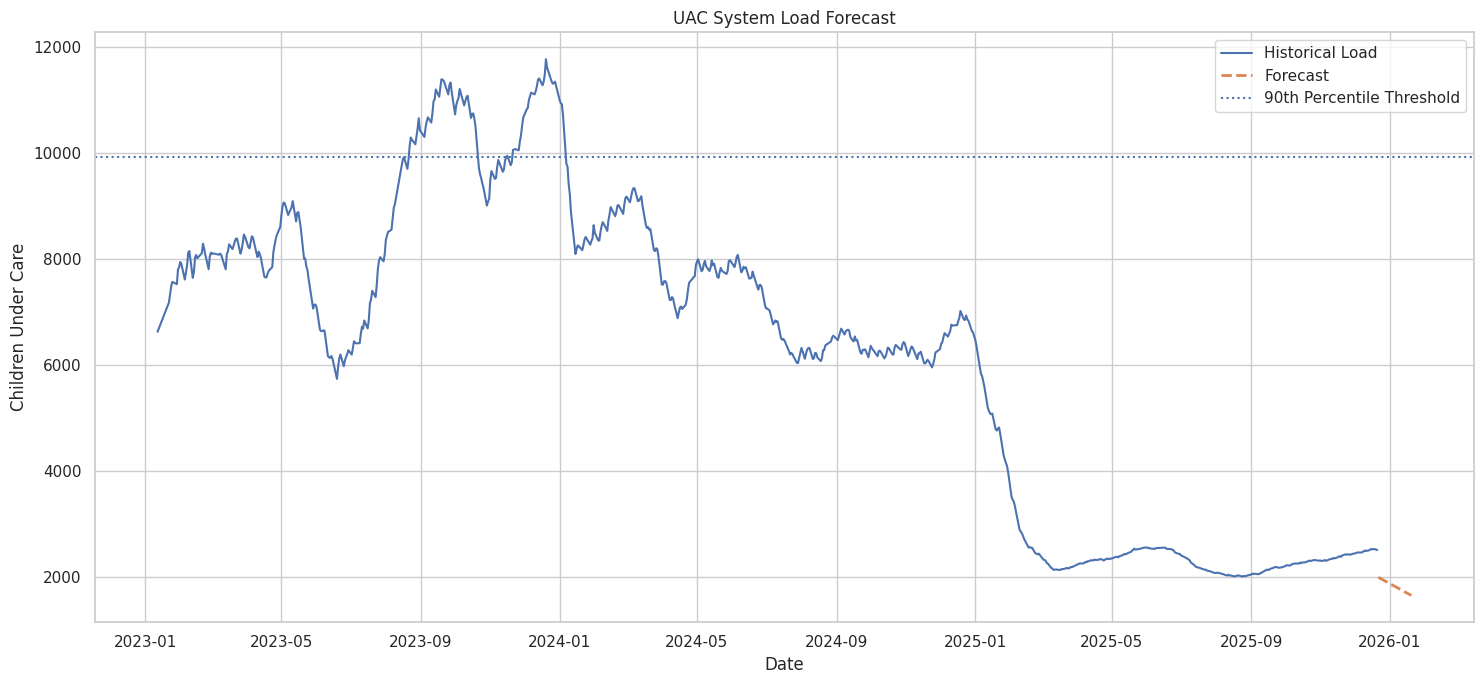

STEP 7 COMPLETE


In [ ]:
# ============================================================
# STEP 7: FINAL PROJECT VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# 1. TOTAL SYSTEM LOAD + ROLLING AVERAGES
# ------------------------------------------------------------

plt.figure(figsize=(15, 7))

plt.plot(
    data["date"],
    data["total_children_under_care"],
    label="Total System Load",
    alpha=0.6
)

plt.plot(
    data["date"],
    data["system_load_7day_avg"],
    label="7-Period Average",
    linewidth=2
)

plt.plot(
    data["date"],
    data["system_load_14day_avg"],
    label="14-Period Average",
    linewidth=2
)

plt.axhline(
    p90_load,
    linestyle="--",
    label="90th Percentile"
)

plt.title("UAC Total System Load and Capacity Threshold")
plt.xlabel("Date")
plt.ylabel("Children Under Care")
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. CBP VS HHS CARE LOAD
# ------------------------------------------------------------

plt.figure(figsize=(15, 7))

plt.plot(
    data["date"],
    data["children_in_cbp_custody"],
    label="CBP Custody"
)

plt.plot(
    data["date"],
    data["children_in_hhs_care"],
    label="HHS Care"
)

plt.title("CBP and HHS Care Load Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Children")
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. NET INTAKE PRESSURE
# ------------------------------------------------------------

plt.figure(figsize=(15, 7))

plt.plot(
    data["date"],
    data["net_intake_kpi"],
    label="Net Intake Pressure",
    alpha=0.5
)

plt.plot(
    data["date"],
    data["backlog_accumulation_rate"],
    label="7-Period Backlog Average",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Net Intake Pressure and Backlog Accumulation")
plt.xlabel("Date")
plt.ylabel("Children")

plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. MONTHLY SYSTEM LOAD
# ------------------------------------------------------------

monthly_system_load = (
    data
    .set_index("date")["total_children_under_care"]
    .resample("ME")
    .mean()
)

plt.figure(figsize=(15, 7))

plt.plot(
    monthly_system_load.index,
    monthly_system_load.values,
    marker="o"
)

plt.title("Monthly Average UAC System Load")
plt.xlabel("Month")
plt.ylabel("Average Children Under Care")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. YEARLY AVERAGE SYSTEM LOAD
# ------------------------------------------------------------

yearly_load = (
    data
    .groupby("year")["total_children_under_care"]
    .mean()
)

plt.figure(figsize=(9, 6))

yearly_load.plot(
    kind="bar"
)

plt.title("Average System Load by Year")
plt.xlabel("Year")
plt.ylabel("Average Children Under Care")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. CAPACITY LOAD CLASSIFICATION
# ------------------------------------------------------------

load_distribution = (
    data["load_level"]
    .value_counts()
    .reindex(
        ["Normal", "Elevated", "High", "Very High"],
        fill_value=0
    )
)

plt.figure(figsize=(10, 6))

load_distribution.plot(
    kind="bar"
)

plt.title("Distribution of Capacity Load Levels")
plt.xlabel("Load Level")
plt.ylabel("Number of Reporting Periods")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. HHS CARE POPULATION
# ------------------------------------------------------------

plt.figure(figsize=(15, 7))

plt.plot(
    data["date"],
    data["children_in_hhs_care"]
)

plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. FORECAST VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(15, 7))

plt.plot(
    forecast_data["date"],
    forecast_data["total_children_under_care"],
    label="Historical Load"
)

plt.plot(
    forecast["date"],
    forecast["forecast_system_load"],
    linestyle="--",
    linewidth=2,
    label="Forecast"
)

plt.axhline(
    p90_load,
    linestyle=":",
    label="90th Percentile Threshold"
)

plt.title("UAC System Load Forecast")
plt.xlabel("Date")
plt.ylabel("Children Under Care")

plt.legend()

plt.tight_layout()
plt.show()


print("=" * 70)
print("STEP 7 COMPLETE")
print("=" * 70)

In [ ]:
# ============================================================
# STEP 8: EXECUTIVE SUMMARY & KEY FINDINGS
# ============================================================

print("=" * 80)
print("UAC SYSTEM CAPACITY & CARE LOAD ANALYTICS")
print("EXECUTIVE SUMMARY")
print("=" * 80)

# ------------------------------------------------------------
# BASIC SYSTEM STATISTICS
# ------------------------------------------------------------

total_periods = len(data)

start_date = data["date"].min()
end_date = data["date"].max()

average_load = data["total_children_under_care"].mean()
peak_load = data["total_children_under_care"].max()
minimum_load = data["total_children_under_care"].min()

peak_row = data.loc[
    data["total_children_under_care"].idxmax()
]

minimum_row = data.loc[
    data["total_children_under_care"].idxmin()
]

# ------------------------------------------------------------
# FLOW STATISTICS
# ------------------------------------------------------------

total_apprehended = data[
    "children_apprehended_cbp"
].sum()

total_transferred = data[
    "children_transferred_out_cbp"
].sum()

total_discharged = data[
    "children_discharged_hhs"
].sum()

average_net_intake = data[
    "net_intake_kpi"
].mean()

# ------------------------------------------------------------
# CAPACITY LEVELS
# ------------------------------------------------------------

normal_periods = (
    data["load_level"] == "Normal"
).sum()

elevated_periods = (
    data["load_level"] == "Elevated"
).sum()

high_periods = (
    data["load_level"] == "High"
).sum()

very_high_periods = (
    data["load_level"] == "Very High"
).sum()

# ------------------------------------------------------------
# YEARLY COMPARISON
# ------------------------------------------------------------

yearly_summary = (
    data
    .groupby("year")
    .agg(
        average_load=(
            "total_children_under_care",
            "mean"
        ),
        peak_load=(
            "total_children_under_care",
            "max"
        ),
        average_net_intake=(
            "net_intake_kpi",
            "mean"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# CAPACITY CHANGE
# ------------------------------------------------------------

first_year_load = yearly_summary.iloc[0]["average_load"]
last_year_load = yearly_summary.iloc[-1]["average_load"]

overall_load_change_percent = (
    (last_year_load - first_year_load)
    / first_year_load
) * 100

# ------------------------------------------------------------
# PROLONGED HIGH LOAD
# ------------------------------------------------------------

number_of_stress_windows = len(
    stress_windows
)

longest_stress_window = (
    stress_windows["periods"].max()
    if len(stress_windows) > 0
    else 0
)

# ------------------------------------------------------------
# CREATE FINDINGS TABLE
# ------------------------------------------------------------

executive_findings = pd.DataFrame({

    "Finding": [
        "Average system load",
        "Peak system load",
        "Lowest system load",
        "Average net intake pressure",
        "Total children apprehended",
        "Total children transferred",
        "Total children discharged",
        "Elevated-load periods",
        "High-load periods",
        "Very-high-load periods",
        "Prolonged high-load windows",
        "Longest high-load window",
        "Change in average load from first to last year"
    ],

    "Value": [
        f"{average_load:,.2f} children",
        f"{peak_load:,.0f} children",
        f"{minimum_load:,.0f} children",
        f"{average_net_intake:,.2f} children/period",
        f"{total_apprehended:,.0f}",
        f"{total_transferred:,.0f}",
        f"{total_discharged:,.0f}",
        f"{elevated_periods}",
        f"{high_periods}",
        f"{very_high_periods}",
        f"{number_of_stress_windows}",
        f"{longest_stress_window} reporting periods",
        f"{overall_load_change_percent:.2f}%"
    ]
})

# ------------------------------------------------------------
# DISPLAY EXECUTIVE FINDINGS
# ------------------------------------------------------------

print("\nKEY PROJECT FINDINGS:")
display(executive_findings)

# ------------------------------------------------------------
# PEAK LOAD DETAILS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PEAK CAPACITY EVENT")
print("=" * 80)

print(
    f"Date: {peak_row['date'].date()}"
)

print(
    f"Total children under care: "
    f"{peak_row['total_children_under_care']:,.0f}"
)

print(
    f"Children in CBP custody: "
    f"{peak_row['children_in_cbp_custody']:,.0f}"
)

print(
    f"Children in HHS care: "
    f"{peak_row['children_in_hhs_care']:,.0f}"
)

# ------------------------------------------------------------
# LOWEST LOAD DETAILS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOWEST CAPACITY LOAD")
print("=" * 80)

print(
    f"Date: {minimum_row['date'].date()}"
)

print(
    f"Total children under care: "
    f"{minimum_row['total_children_under_care']:,.0f}"
)

print(
    f"Children in CBP custody: "
    f"{minimum_row['children_in_cbp_custody']:,.0f}"
)

print(
    f"Children in HHS care: "
    f"{minimum_row['children_in_hhs_care']:,.0f}"
)

# ------------------------------------------------------------
# YEARLY SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("YEARLY CAPACITY SUMMARY")
print("=" * 80)

display(
    yearly_summary.round(2)
)

# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXECUTIVE INTERPRETATION")
print("=" * 80)

print(
    f"""
1. The system managed an average of approximately
   {average_load:,.0f} children under combined CBP and HHS care
   during the study period.

2. The highest recorded system inventory was
   {peak_load:,.0f} children on {peak_row['date'].date()}.

3. The lowest recorded inventory was
   {minimum_load:,.0f} children on {minimum_row['date'].date()}.

4. Average net intake pressure was
   {average_net_intake:,.2f} children per reporting period.
   A negative value indicates that HHS discharges generally
   exceeded transfers into HHS during the study period.

5. The analysis identified {very_high_periods} very-high-load
   reporting periods and {high_periods} high-load periods.

6. There were {number_of_stress_windows} prolonged high-load
   windows lasting at least three reporting periods.

7. The longest identified high-load window lasted
   {longest_stress_window} reporting periods.

8. Average system load changed by approximately
   {overall_load_change_percent:.2f}% between the first and
   last year represented in the dataset.

These findings indicate substantial variation in system care
load over time, with distinct periods of elevated capacity
pressure followed by periods of system relief.
"""
)

print("\nSTEP 8 COMPLETE!")
print("=" * 80)

UAC SYSTEM CAPACITY & CARE LOAD ANALYTICS
EXECUTIVE SUMMARY

KEY PROJECT FINDINGS:


,Finding,Value
0,Average system load,"6,232.77 children"
1,Peak system load,"11,762 children"
2,Lowest system load,"2,002 children"
3,Average net intake pressure,-44.74 children/period
4,Total children apprehended,"67,337"
5,Total children transferred,"92,641"
6,Total children discharged,"124,853"
7,Elevated-load periods,108
8,High-load periods,36
9,Very-high-load periods,36



PEAK CAPACITY EVENT
Date: 2023-12-20
Total children under care: 11,762
Children in CBP custody: 246
Children in HHS care: 11,516

LOWEST CAPACITY LOAD
Date: 2025-08-24
Total children under care: 2,002
Children in CBP custody: 21
Children in HHS care: 1,981

YEARLY CAPACITY SUMMARY


,year,average_load,peak_load,average_net_intake
0,2023,8846.54,11762,-130.96
1,2024,7319.86,10994,3.44
2,2025,2575.74,6471,-12.36



EXECUTIVE INTERPRETATION

1. The system managed an average of approximately
   6,233 children under combined CBP and HHS care
   during the study period.

2. The highest recorded system inventory was
   11,762 children on 2023-12-20.

3. The lowest recorded inventory was
   2,002 children on 2025-08-24.

4. Average net intake pressure was
   -44.74 children per reporting period.
   A negative value indicates that HHS discharges generally
   exceeded transfers into HHS during the study period.

5. The analysis identified 36 very-high-load
   reporting periods and 36 high-load periods.

6. There were 2 prolonged high-load
   windows lasting at least three reporting periods.

7. The longest identified high-load window lasted
   41 reporting periods.

8. Average system load changed by approximately
   -70.88% between the first and
   last year represented in the dataset.

These findings indicate substantial variation in system care
load over time, with distinct periods of elevated capacit

In [ ]:
# ============================================================
# STEP 9: EXPORT FINAL ANALYSIS FILES
# ============================================================

import os

print("=" * 80)
print("STEP 9: EXPORTING FINAL ANALYSIS FILES")
print("=" * 80)

# ------------------------------------------------------------
# 1. EXPORT COMPLETE ANALYTICAL DATASET
# ------------------------------------------------------------

final_data_path = "UAC_System_Capacity_Complete_Analysis.csv"

data.to_csv(
    final_data_path,
    index=False
)

print(f"\nComplete analytical dataset saved as:")
print(final_data_path)


# ------------------------------------------------------------
# 2. EXPORT KPI SUMMARY
# ------------------------------------------------------------

kpi_path = "UAC_System_Capacity_KPI_Summary.csv"

final_kpi_summary.to_csv(
    kpi_path,
    index=False
)

print(f"\nKPI summary saved as:")
print(kpi_path)


# ------------------------------------------------------------
# 3. EXPORT YEARLY CAPACITY SUMMARY
# ------------------------------------------------------------

yearly_path = "UAC_Yearly_Capacity_Summary.csv"

yearly_summary.to_csv(
    yearly_path,
    index=False
)

print(f"\nYearly capacity summary saved as:")
print(yearly_path)


# ------------------------------------------------------------
# 4. EXPORT TOP HIGH-LOAD PERIODS
# ------------------------------------------------------------

high_load_path = "UAC_Top_High_Load_Periods.csv"

top_high_load.to_csv(
    high_load_path,
    index=False
)

print(f"\nHigh-load periods saved as:")
print(high_load_path)


# ------------------------------------------------------------
# 5. EXPORT PROLONGED STRESS WINDOWS
# ------------------------------------------------------------

stress_path = "UAC_Prolonged_High_Load_Windows.csv"

stress_windows.to_csv(
    stress_path,
    index=False
)

print(f"\nProlonged stress windows saved as:")
print(stress_path)


# ------------------------------------------------------------
# 6. EXPORT RELIEF PERIODS
# ------------------------------------------------------------

relief_path = "UAC_Capacity_Relief_Periods.csv"

top_relief.to_csv(
    relief_path,
    index=False
)

print(f"\nRelief periods saved as:")
print(relief_path)


# ------------------------------------------------------------
# 7. EXPORT FORECAST
# ------------------------------------------------------------

forecast_path = "UAC_System_Load_Forecast.csv"

forecast.to_csv(
    forecast_path,
    index=False
)

print(f"\nForecast saved as:")
print(forecast_path)


# ------------------------------------------------------------
# 8. EXPORT EXECUTIVE FINDINGS
# ------------------------------------------------------------

findings_path = "UAC_Executive_Findings.csv"

executive_findings.to_csv(
    findings_path,
    index=False
)

print(f"\nExecutive findings saved as:")
print(findings_path)


# ------------------------------------------------------------
# 9. CHECK FILES
# ------------------------------------------------------------

exported_files = [
    final_data_path,
    kpi_path,
    yearly_path,
    high_load_path,
    stress_path,
    relief_path,
    forecast_path,
    findings_path
]

print("\n" + "=" * 80)
print("EXPORTED FILES")
print("=" * 80)

for file in exported_files:
    if os.path.exists(file):
        size_kb = os.path.getsize(file) / 1024
        print(f"✓ {file} ({size_kb:.1f} KB)")
    else:
        print(f"✗ {file} NOT FOUND")


# ------------------------------------------------------------
# 10. CREATE ONE MASTER EXCEL FILE
# ------------------------------------------------------------

excel_path = "UAC_System_Capacity_Analytics_Final.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    data.to_excel(
        writer,
        sheet_name="Complete Analysis",
        index=False
    )

    final_kpi_summary.to_excel(
        writer,
        sheet_name="KPI Summary",
        index=False
    )

    yearly_summary.to_excel(
        writer,
        sheet_name="Yearly Summary",
        index=False
    )

    top_high_load.to_excel(
        writer,
        sheet_name="High Load Periods",
        index=False
    )

    stress_windows.to_excel(
        writer,
        sheet_name="Stress Windows",
        index=False
    )

    top_relief.to_excel(
        writer,
        sheet_name="Relief Periods",
        index=False
    )

    forecast.to_excel(
        writer,
        sheet_name="Forecast",
        index=False
    )

    executive_findings.to_excel(
        writer,
        sheet_name="Executive Findings",
        index=False
    )

print("\nMaster Excel workbook saved as:")
print(excel_path)


print("\n" + "=" * 80)
print("STEP 9 COMPLETE!")
print("=" * 80)

STEP 9: EXPORTING FINAL ANALYSIS FILES

Complete analytical dataset saved as:
UAC_System_Capacity_Complete_Analysis.csv

KPI summary saved as:
UAC_System_Capacity_KPI_Summary.csv

Yearly capacity summary saved as:
UAC_Yearly_Capacity_Summary.csv

High-load periods saved as:
UAC_Top_High_Load_Periods.csv

Prolonged stress windows saved as:
UAC_Prolonged_High_Load_Windows.csv

Relief periods saved as:
UAC_Capacity_Relief_Periods.csv

Forecast saved as:
UAC_System_Load_Forecast.csv

Executive findings saved as:
UAC_Executive_Findings.csv

EXPORTED FILES
✓ UAC_System_Capacity_Complete_Analysis.csv (195.1 KB)
✓ UAC_System_Capacity_KPI_Summary.csv (0.4 KB)
✓ UAC_Yearly_Capacity_Summary.csv (0.2 KB)
✓ UAC_Top_High_Load_Periods.csv (1.3 KB)
✓ UAC_Prolonged_High_Load_Windows.csv (0.1 KB)
✓ UAC_Capacity_Relief_Periods.csv (0.7 KB)
✓ UAC_System_Load_Forecast.csv (0.9 KB)
✓ UAC_Executive_Findings.csv (0.5 KB)

Master Excel workbook saved as:
UAC_System_Capacity_Analytics_Final.xlsx

STEP 9 COMPLET

In [15]:
import os
import zipfile
from google.colab import files

files_to_download = [
    "UAC_System_Capacity_Complete_Analysis.csv",
    "UAC_System_Capacity_KPI_Summary.csv",
    "UAC_Yearly_Capacity_Summary.csv",
    "UAC_Top_High_Load_Periods.csv",
    "UAC_Prolonged_High_Load_Windows.csv",
    "UAC_Capacity_Relief_Periods.csv",
    "UAC_System_Load_Forecast.csv",
    "UAC_Executive_Findings.csv",
    "UAC_System_Capacity_Analytics_Final.xlsx"
]

zip_name = "UAC_System_Capacity_Analytics_Files.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:
    for file_name in files_to_download:
        if os.path.exists(file_name):
            zipf.write(file_name)
            print("Added:", file_name)
        else:
            print("Not found:", file_name)

print("\nZIP file created:", zip_name)

files.download(zip_name)

Added: UAC_System_Capacity_Complete_Analysis.csv
Added: UAC_System_Capacity_KPI_Summary.csv
Added: UAC_Yearly_Capacity_Summary.csv
Added: UAC_Top_High_Load_Periods.csv
Added: UAC_Prolonged_High_Load_Windows.csv
Added: UAC_Capacity_Relief_Periods.csv
Added: UAC_System_Load_Forecast.csv
Added: UAC_Executive_Findings.csv
Added: UAC_System_Capacity_Analytics_Final.xlsx

ZIP file created: UAC_System_Capacity_Analytics_Files.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>